In [1]:
import pickle
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

# Load everything — no training needed
model      = load_model("caption_model.keras")
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)
with open("max_length.pkl", "rb") as f:
    max_length = pickle.load(f)

print("Ready! Model loaded successfully.")
print("Vocab size:", len(tokenizer.word_index) + 1)
print("Max length:", max_length)

Ready! Model loaded successfully.
Vocab size: 19774
Max length: 80


# Data Preprocessing

In [5]:
import kagglehub

path = kagglehub.dataset_download("hsankesara/flickr-image-dataset")

print(path)

c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\DELL\.cache\kagglehub\datasets\hsankesara\flickr-image-dataset\versions\1


In [6]:
import os

print(os.listdir(path))

['flickr30k_images']


In [7]:
folder_path = path + "/flickr30k_images"

print(os.listdir(folder_path)[:10])

['flickr30k_images', 'results.csv']


In [8]:
import pandas as pd

csv_path = folder_path + "/results.csv"

df = pd.read_csv(csv_path, delimiter="|")

print(df.head())
print(df.columns)

       image_name  comment_number  \
0  1000092795.jpg               0   
1  1000092795.jpg               1   
2  1000092795.jpg               2   
3  1000092795.jpg               3   
4  1000092795.jpg               4   

                                             comment  
0   Two young guys with shaggy hair look at their...  
1   Two young , White males are outside near many...  
2   Two men in green shirts are standing in a yard .  
3       A man in a blue shirt standing in a garden .  
4            Two friends enjoy time spent together .  
Index(['image_name', ' comment_number', ' comment'], dtype='str')


In [9]:
# column names have leading and trailing spaces, so we need to strip them
df.columns = df.columns.str.strip()

print(df.columns)

Index(['image_name', 'comment_number', 'comment'], dtype='str')


In [10]:
import re

df["comment"] = df["comment"].astype(str)

def clean_caption(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

df["comment"] = df["comment"].apply(clean_caption)
df["comment"] = df["comment"].apply(
    lambda x: "startseq " + x + " endseq"
)

df.head()

,image_name,comment_number,comment
0,1000092795.jpg,0,startseq two young guys with shaggy hair look ...
1,1000092795.jpg,1,startseq two young white males are outside nea...
2,1000092795.jpg,2,startseq two men in green shirts are standing ...
3,1000092795.jpg,3,startseq a man in a blue shirt standing in a g...
4,1000092795.jpg,4,startseq two friends enjoy time spent together...


## Tokenization

In this step, captions are converted into numerical sequences using a tokenizer.  
Each word is mapped to a unique integer value to prepare the text data for deep learning models.

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Increased vocab 8000 to capture more words
tokenizer = Tokenizer(
    num_words=8000,
    oov_token="<unk>"
)

tokenizer.fit_on_texts(df["comment"])

# Cap vocab_size to match num_words so output layer isn't oversized
vocab_size = min(len(tokenizer.word_index) + 1, 8001)

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 8001


In [12]:
max_length = max(
    df["comment"].apply(lambda x: len(x.split()))
)

print("Max Length:", max_length)

sequences = tokenizer.texts_to_sequences(df["comment"])

print(sequences[0])

Max Length: 80
[3, 14, 21, 324, 12, 2101, 110, 186, 18, 63, 158, 25, 323, 73, 5, 6, 488, 4]


# EfficientNetB1

In [13]:
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

IMAGE_SIZE = (240, 240)

base_model = EfficientNetB1(
    weights='imagenet',
    include_top=False,
    input_shape=(240, 240, 3)  # FIX: Explicit input shape
)

# Freeze more layers (keep top 20 trainable, not just 10)
# Unfreezing too few layers limits fine-tuning benefit
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

cnn_output = GlobalAveragePooling2D()(base_model.output)

In [14]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from collections import defaultdict
import os
import numpy as np

images_path = path + "/flickr30k_images/flickr30k_images"

df_sample = df.head(6000).dropna(subset=["comment"])
df_sample["comment"] = df_sample["comment"].astype(str)

all_image_names = []
all_in_seqs = []
all_out_seqs = []

for _, row in df_sample.iterrows():
    image_name = row["image_name"]
    caption = row["comment"]
    img_path = images_path + "/" + image_name

    #  Skip missing images before building the dataset
    if not os.path.exists(img_path):
        print(f"Skipping missing image: {image_name}")
        continue

    sequence = tokenizer.texts_to_sequences([caption])[0]

    for i in range(1, len(sequence)):
        in_seq = pad_sequences([sequence[:i]], maxlen=max_length)[0]
        out_seq = sequence[i]

        all_image_names.append(img_path)
        all_in_seqs.append(in_seq)
        all_out_seqs.append(out_seq)

N = 50000
all_image_names = all_image_names[:N]
all_in_seqs     = np.array(all_in_seqs[:N],  dtype="int32")
all_out_seqs    = np.array(all_out_seqs[:N], dtype="int32")

print(f"Total samples: {len(all_image_names)}")

Total samples: 50000


In [15]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

def load_image(img_path, in_seq, out_seq):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [240, 240])
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return (img, in_seq), out_seq

dataset = tf.data.Dataset.from_tensor_slices((
    all_image_names,
    all_in_seqs,
    all_out_seqs
))

BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

dataset = (
    dataset
    .shuffle(buffer_size=5000)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Proper 70/15/15 split
total_batches = len(all_image_names) // BATCH_SIZE
test_size     = int(total_batches * 0.15)
val_size      = int(total_batches * 0.15)

test_ds  = dataset.take(test_size)
val_ds   = dataset.skip(test_size).take(val_size)
train_ds = dataset.skip(test_size + val_size)

print(f"Train batches: {total_batches - test_size - val_size}")
print(f"Val batches:   {val_size}")
print(f"Test batches:  {test_size}")

Train batches: 1094
Val batches:   234
Test batches:  234


# GRU Model

In [12]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, GRU, Dropout, add, LayerNormalization

# Image branch
image_input = base_model.input
img_dropout = Dropout(0.3)(cnn_output)
img_dense   = Dense(512, activation='relu')(img_dropout)
img_norm    = LayerNormalization()(img_dense)

# Text branch
text_input     = Input(shape=(max_length,))
text_embedding = Embedding(input_dim=vocab_size, output_dim=512, mask_zero=True)(text_input)
text_dropout   = Dropout(0.3)(text_embedding)

# FIX: use_cudnn=False to allow mask_zero=True on GPU
text_gru       = GRU(512, use_cudnn=False)(text_dropout)
text_norm      = LayerNormalization()(text_gru)

# Combine
decoder       = add([img_norm, text_norm])
decoder_dense = Dense(512, activation='relu')(decoder)
decoder_dense = Dropout(0.3)(decoder_dense)
output        = Dense(vocab_size, activation='softmax')(decoder_dense)

model = Model(inputs=[image_input, text_input], outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 240, 240,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 240, 240,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 240, 240,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 17,272,776 (65.89 MB)

 Trainable params: 13,042,577 (49.75 MB)

 Non-trainable params: 4,230,199 (16.14 MB)

In [13]:
from tensorflow.keras.optimizers import Adam

#  Increased learning rate from 1e-5 -> 1e-4 (faster convergence)
# 1e-5 is too conservative and makes the model learn extremely slowly
optimizer = Adam(
    learning_rate=1e-4,
    clipnorm=1.0
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# Training Model

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 301s 190ms/step - accuracy: 0.2085 - loss: 5.2795 - val_accuracy: 0.2610 - val_loss: 4.5989 - learning_rate: 1.0000e-04
Epoch 2/30
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 198s 150ms/step - accuracy: 0.2847 - loss: 4.1724 - val_accuracy: 0.2894 - val_loss: 4.2123 - learning_rate: 1.0000e-04
Epoch 3/30
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 197s 149ms/step - accuracy: 0.3229 - loss: 3.7182 - val_accuracy: 0.3212 - val_loss: 4.0084 - learning_rate: 1.0000e-04
Epoch 4/30
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 202s 153ms/step - accuracy: 0.3544 - loss: 3.3551 - val_accuracy: 0.3416 - val_loss: 3.8262 - learning_rate: 1.0000e-04
Epoch 5/30
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 197s 150ms/step - accuracy: 0.3813 - loss: 3.0570 - val_accuracy: 0.3547 - val_loss: 3.6625 - learning_rate: 1.0000e-04
Epoch 6/30
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 203s 151ms/step - accuracy: 0.4127 - loss: 2.7780 - val_accuracy: 0.3602 - val_loss: 3.5791 - learning_rate: 1.0000e-04
Epoch 7/30
1095/1095 ━━━━━━━

 **Save Training**

In [20]:

import os

# Create the folder first
os.makedirs("/content/drive/MyDrive/captioning_model", exist_ok=True)

# Then save
model.save("/content/drive/MyDrive/captioning_model/best_model.keras")
print("Saved safely! ✅")

Saved safely! ✅


In [19]:
import pickle

# Save the model
model.save("caption_model.keras")

# Save the tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save max_length
with open("max_length.pkl", "wb") as f:
    pickle.dump(max_length, f)

print("All saved!")

All saved!


In [30]:
import zipfile
from google.colab import files

# Zip all 3 files into one folder
with zipfile.ZipFile("captioning_project.zip", "w") as zipf:
    zipf.write("caption_model.keras")
    zipf.write("tokenizer.pkl")
    zipf.write("max_length.pkl")

print("Zipped! ✅")

# Download the zip
files.download("captioning_project.zip")

Zipped! ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Visualization of Training**

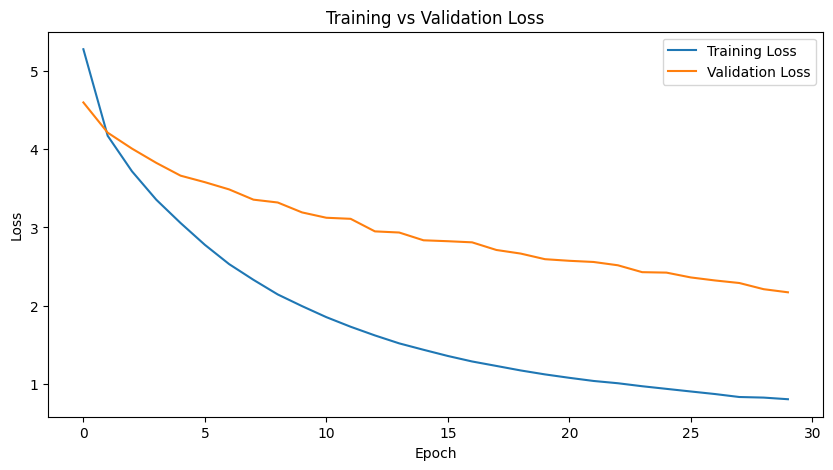

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

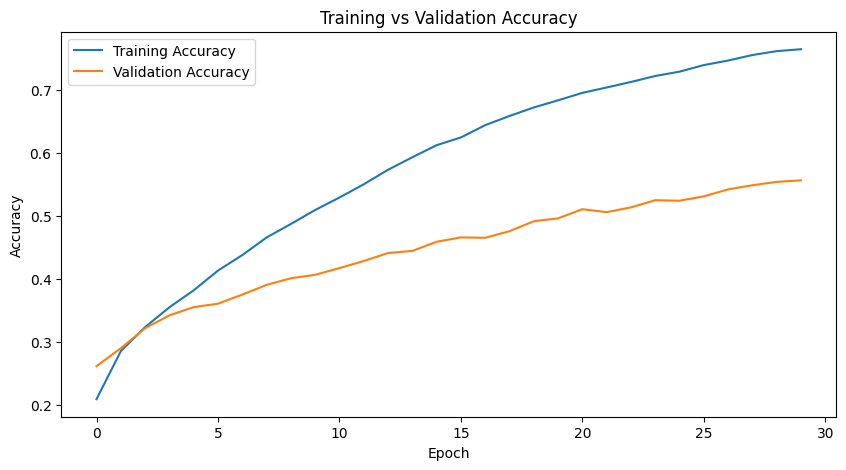

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

**TEST**

In [23]:
test_results = model.evaluate(test_ds)
print(f"Test Loss:     {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")

234/234 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - accuracy: 0.4017 - loss: 3.7123
Test Loss:     3.7123
Test Accuracy: 0.4017


In [16]:
def generate_caption(model, tokenizer, img_array, max_length):
    # Start with the start token
    in_seq = tokenizer.texts_to_sequences(['startseq'])[0]

    for _ in range(max_length):
        # Pad sequence
        in_seq_padded = tf.keras.preprocessing.sequence.pad_sequences(
            [in_seq], maxlen=max_length, padding='post'
        )

        # Predict next word
        yhat = model.predict([img_array, in_seq_padded], verbose=0)
        yhat_idx = np.argmax(yhat)

        # Convert index to word
        word = tokenizer.index_word.get(yhat_idx, None)

        # Stop if endseq or unknown
        if word is None or word == 'endseq':
            break

        in_seq.append(yhat_idx)

    # Decode full caption (skip startseq)
    caption_words = [
        tokenizer.index_word.get(idx, '')
        for idx in in_seq[1:]  # skip startseq token
    ]
    return ' '.join(caption_words)

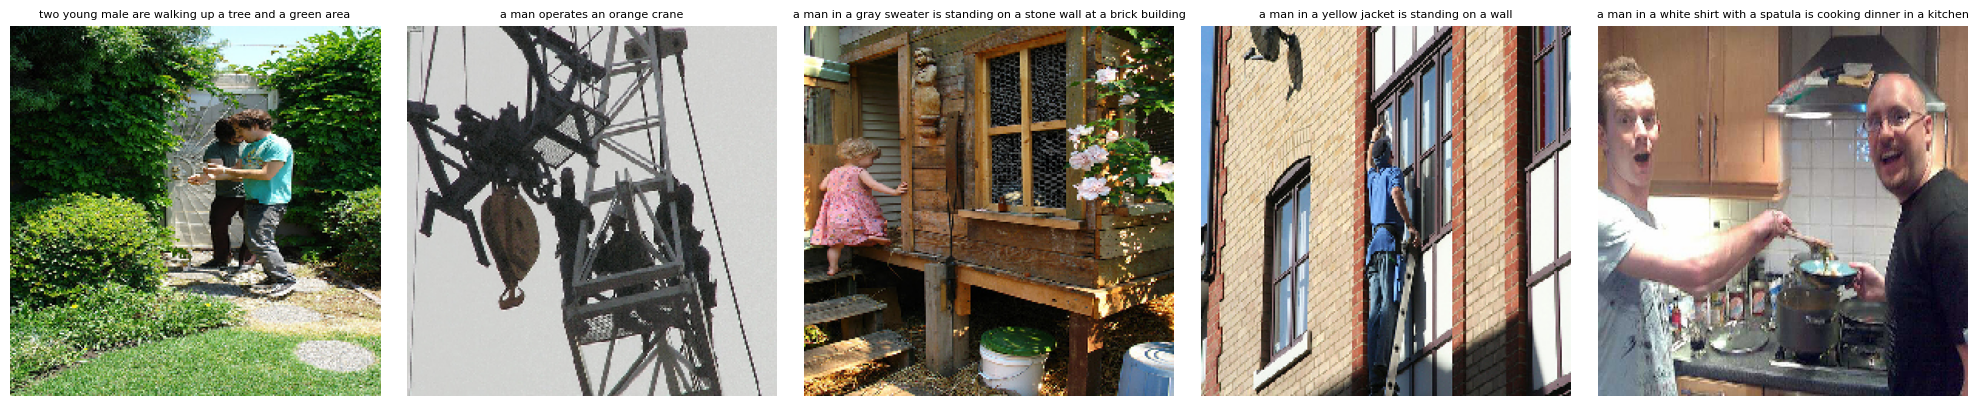

In [17]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import os


test_images = os.listdir(images_path)[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, img_name in enumerate(test_images):
    img_path = images_path + "/" + img_name

    # Generate caption
    img = image.load_img(img_path, target_size=(240, 240))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    caption = generate_caption(model, tokenizer, img_array, max_length)

    # Show
    axes[i].imshow(img)
    axes[i].set_title(caption, fontsize=8, wrap=True)
    axes[i].axis("off")

plt.tight_layout()
plt.show()